# MLOps with MLflow Esercizio

In [ ]:
# Imports
import os
# Aggiungo per caricare il file .env
from dotenv import load_dotenv

import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import load_wine, load_iris

## To do
Make sure:
*   Workspace created
*   Catalog and schema exist
*   Volume exists
*   Permissions set correctly

Now, let's:
*   Geneartes Token
*   Create Experiments   

Su **databricks** ho creato:
* in Catalog > Volumes > workspace.default.mlops_experiments
* In models > workspace.default.wine_classification_mlops
* Ho generato il token e ho creato un file `.env` da cui prendo le informazioni:
```
DATABRICKS_HOST=XXX
DATABRICKS_TOKEN=XXX
MLFLOW_EXPERIMENT_NAME=XXX
MLFLOW_ARTIFACT_LOCATION=XXX
```

## Imposto l'esperimento e dove salvare gli artefatti.

In [ ]:
# Carica le variabili dal file .env
load_dotenv()

# Leggi le variabili dal file .env
os.environ["DATABRICKS_HOST"] = os.getenv("DATABRICKS_HOST")
os.environ["DATABRICKS_TOKEN"] = os.getenv("DATABRICKS_TOKEN")

# Imposta l'URI di tracking di MLflow
mlflow.set_tracking_uri("databricks")

# Nome dell'esperimento e posizione degli artifact
experiment_name = os.environ.get("EXPERIMENT_NAME")

artifact_location = "dbfs:/Volumes/workspace/default/mlops_experiments"


# Crea l'esperimento se non esiste già
try:
    mlflow.create_experiment(experiment_name, artifact_location=artifact_location)
except Exception as e:
    if "already exists" in str(e):
        print("Experiment already exists")
    else:
        raise e

# Imposta l'esperimento
mlflow.set_experiment(experiment_name)

## Part 1: Tracking Experiments with MLflow
### Loading and Preprocessing Data
We'll use the wine dataset from scikit-learn, which is a classic classification dataset.

In [21]:
# Load the wine dataset
wine = load_wine()
X = wine.data
y = wine.target

# Convert to pandas DataFrame for better visualization
wine_df = pd.DataFrame(X, columns=wine.feature_names)
wine_df['target'] = y

# Display dataset information
print("Wine Dataset Shape:", wine_df.shape)
print("\nFeature Names:", wine.feature_names)
print("\nTarget Names (Wine Types):", wine.target_names)
print("\nFirst 5 rows of the dataset:")
wine_df.head()

Wine Dataset Shape: (178, 14)

Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Names (Wine Types): ['class_0' 'class_1' 'class_2']

First 5 rows of the dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [22]:
# Basic statistics of the dataset
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


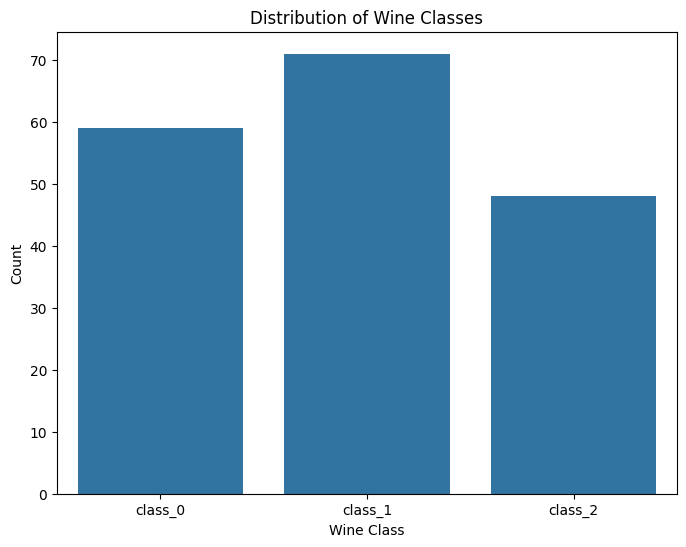

In [23]:
# Visualize distribution of wine classes
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=wine_df)
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.xticks([0, 1, 2], wine.target_names)
plt.savefig('wine_class_distribution.png')
plt.show()

## Splitto i dati in train e test e applico uno standarScaler

In [24]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (142, 13)
Testing set shape: (36, 13)


### Logging Parameters and Metrics with MLflow

Now, let's train a Random Forest classifier and log the experiment with MLflow.

In [25]:
# Define model parameters
n_estimators = 100
max_depth = 10
min_samples_split = 2
random_state = 42

# Start an MLflow run
with mlflow.start_run(run_name="random_forest_classifier") as run:
    # Log parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("random_state", random_state)

    # Train the model
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    clf.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = clf.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    # Print results
    print(f"Model performance metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")

    print(f"\nRun ID: {run.info.run_id}")
    print(f"Experiment ID: {run.info.experiment_id}")

Model performance metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000

Run ID: 0fc398bd4b694b3590bd5705bafd8363
Experiment ID: 1652822730686420
🏃 View run random_forest_classifier at: https://dbc-2b9a920f-a260.cloud.databricks.com/ml/experiments/1652822730686420/runs/0fc398bd4b694b3590bd5705bafd8363
🧪 View experiment at: https://dbc-2b9a920f-a260.cloud.databricks.com/ml/experiments/1652822730686420


Allego screen

![screen](Screen/random-forest-classifier.png)


### Logging Artifacts and Models

Let's create some visualizations and log them as artifacts along with the model:

In [26]:
# Create a new run to log artifacts and model
with mlflow.start_run(run_name="random_forest_with_artifacts") as run:
    # Log the same parameters
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)
    mlflow.log_param("min_samples_split", min_samples_split)
    mlflow.log_param("random_state", random_state)

    # Train the model again
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=random_state
    )
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

    # Log metrics
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    # Log the model
    from mlflow.models import infer_signature
    signature = infer_signature(X_test_scaled, y_pred)

    mlflow.sklearn.log_model(clf,
                             input_example=X_test_scaled[:5],
                             signature=signature,
                             artifact_path="random_forest_model")

    # Create confusion matrix plot
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine.target_names, yticklabels=wine.target_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    # Save confusion matrix plot locally
    confusion_matrix_path = "confusion_matrix.png"
    plt.savefig(confusion_matrix_path)
    plt.close()

    # Create and log feature importance plot
    plt.figure(figsize=(12, 8))
    feature_importances = pd.DataFrame(
        clf.feature_importances_,
        index=wine.feature_names,
        columns=['Importance']
    ).sort_values('Importance', ascending=False)

    sns.barplot(x=feature_importances.Importance, y=feature_importances.index)
    plt.title('Feature Importances')
    plt.tight_layout()

    # Save feature importance plot locally
    feature_importance_path = "feature_importance.png"
    plt.savefig(feature_importance_path)
    plt.close()

    # Log the confusion matrix as an artifact
    mlflow.log_artifact(confusion_matrix_path)

    # Log the feature importance as an artifact
    mlflow.log_artifact(feature_importance_path)

    # Log the scaler as an artifact
    import joblib
    scaler_path = "scaler.joblib"
    joblib.dump(scaler, scaler_path)
    mlflow.log_artifact(scaler_path)

    print(f"Run ID: {run.info.run_id}")
    print(f"Artifacts logged: confusion matrix, feature importance, model, and scaler")

Run ID: 3cb26a89fb674893a6c2594e8ebd0af9
Artifacts logged: confusion matrix, feature importance, model, and scaler
🏃 View run random_forest_with_artifacts at: https://dbc-2b9a920f-a260.cloud.databricks.com/ml/experiments/1652822730686420/runs/3cb26a89fb674893a6c2594e8ebd0af9
🧪 View experiment at: https://dbc-2b9a920f-a260.cloud.databricks.com/ml/experiments/1652822730686420


### Allego screen

![artifacts](Screen/random-forest-artifact.png)

## Creo un ulteriore modellocon dei parametri tramite `GridSearchCV`
Uso `GridSearchCv`con una `param_grid` per poter generare varie combinazioni



In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}

# GridSearchCV
svm_grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
svm_grid.fit(X_train_scaled, y_train)

# Get the best parameters and model
best_params = svm_grid.best_params_
best_model = svm_grid.best_estimator_

# Log the best model with its parameters
with mlflow.start_run(run_name="best_svm_model") as run:
    # Log parameters
    for param, value in best_params.items():
        mlflow.log_param(param, value)

    # Make predictions
    y_pred = best_model.predict(X_test_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)

    from mlflow.models import infer_signature
    signature = infer_signature(X_test_scaled, y_pred)

    # Log the model
    conda_env = mlflow.sklearn.get_default_conda_env()
    mlflow.sklearn.log_model(best_model,
                             artifact_path="svm_model",
                             signature=signature,
                             input_example=X_test_scaled[:5],
                             conda_env=conda_env)

    print(f"Best SVM parameters: {best_params}")
    print(f"Model performance metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")

Best SVM parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Model performance metrics:
  Accuracy: 0.9722
  Precision: 0.9753
  Recall: 0.9722
  F1 Score: 0.9725
🏃 View run best_svm_model at: https://dbc-2b9a920f-a260.cloud.databricks.com/ml/experiments/1652822730686420/runs/416e001584d546a5b97f1466d3c4dde1
🧪 View experiment at: https://dbc-2b9a920f-a260.cloud.databricks.com/ml/experiments/1652822730686420


Screen

![best_model](Screen/best.png)

## Registro ill modello e Deployment

### Loading Models and Inference


In [12]:
# recupero ID del moello
run.info.run_id

'416e001584d546a5b97f1466d3c4dde1'

In [13]:
mlflow.set_registry_uri("databricks-uc")

In [14]:
model_uri = f"runs:/{run.info.run_id}/svm_model"

In [15]:
# Get the run ID of our best Random Forest model
best_rf_run_id = run.info.run_id  # Using the last run ID from the previous cell, replace if needed

# Register the model in the Model Registry
model_name = "WineClassifier"
model_version = mlflow.register_model(model_uri=model_uri, name=f"workspace.default.{model_name}")

print(f"Model registered with name: {model_name}")
print(f"Model version: {model_version.version}")

Successfully registered model 'workspace.default.wineclassifier'.


Model registered with name: WineClassifier
Model version: 1


Created version '1' of model 'workspace.default.wineclassifier'.


Screen modello salvato

![best_model](Screen/saved-model.png)

## Assegno Alias Champion

In [17]:
from mlflow import MlflowClient

client = MlflowClient()

# Prima assegna l'alias
client.set_registered_model_alias(
    f"workspace.default.{model_name}",
    "Champion",
    version=1  # Sostituisci con la versione corretta del tuo modello
)

# Poi recupera il modello con quell'alias
model_version = client.get_model_version_by_alias(f"workspace.default.{model_name}", "Champion")

Screen assegnazione Alias **Champion**

![best_model](Screen/champion.png)

## Caricare il modello dal registro tramite versione

In [18]:
# Load a model from the model registry by name and stage
loaded_model = mlflow.pyfunc.load_model(f"models:/workspace.default.{model_name}/{model_version.version}")

# Make predictions
predictions = loaded_model.predict(X_test_scaled)

# Evaluate the loaded model
accuracy = accuracy_score(y_test, predictions)
print(f"Loaded model accuracy: {accuracy:.4f}")

# Example of single prediction (for a deployed model scenario)
single_sample = X_test_scaled[0:1]  # Get the first sample from the test data
single_prediction = loaded_model.predict(single_sample)[0]
print(f"Predicted wine class: {wine.target_names[single_prediction]}")

# Let's create a sample inference request that would be used in a REST API
# We need to convert the numpy array to a list for JSON serialization
import json

sample_input = {
    "columns": wine.feature_names,
    "data": X_test_scaled[0:3].tolist()  # Send 3 samples for prediction
}

print("Sample inference request payload:")
print(json.dumps(sample_input, indent=4))

# In a real-world scenario, you'd send this to an API endpoint
# Here we'll simulate the inference locally
predictions = loaded_model.predict(np.array(sample_input["data"]))
print("\nPredictions:", [wine.target_names[p] for p in predictions])

Loaded model accuracy: 0.9722
Predicted wine class: class_0
Sample inference request payload:
{
    "columns": [
        "alcohol",
        "malic_acid",
        "ash",
        "alcalinity_of_ash",
        "magnesium",
        "total_phenols",
        "flavanoids",
        "nonflavanoid_phenols",
        "proanthocyanins",
        "color_intensity",
        "hue",
        "od280/od315_of_diluted_wines",
        "proline"
    ],
    "data": [
        [
            0.8087333750747496,
            0.6373187412153807,
            0.7157857907062193,
            -1.241280355132674,
            1.0655672175876452,
            0.6466366889064011,
            1.027242366854435,
            -1.549320936237817,
            0.08936052953773631,
            0.01825222796978623,
            0.015516948246124351,
            1.0661342138680752,
            0.36548715111247965
        ],
        [
            1.5062174387779945,
            1.4619533435557168,
            0.28449194793274324,
       

## Serving The Model
Let's see how to serve the model using MLflow's built-in model server:

Al momento farò lo step da **DataBricks**

![serving](Screen/serving.png)

Dopo aver cliccato su Serve Model, procedo alla creazione dei vari endpoint.

Processo Ultimato, Allego Screen:

![Serving](Screen/serving_2.png)
![Serving](Screen/serving_3.png)